## 1. Import Required Libraries

In [ ]:
import os

import matplotlib.pyplot as plt
import numpy as np
from mpi4py import MPI

# Import cosmocore modules
from cosmocore import (
    InputParams,
    compute_signal_matrix,
    read_maps,
)

# Import qube modules
from picslike import PICSLike

# Set up plotting style
plt.style.use("default")
plt.rcParams["figure.figsize"] = (12, 8)

print("All imports successful!")
print(f"MPI size: {MPI.COMM_WORLD.Get_size()}, rank: {MPI.COMM_WORLD.Get_rank()}")

In [93]:
def configure_plt():
    plt.rc("axes", labelsize=20, linewidth=1.5)
    plt.rc("xtick", direction="in", labelsize=15, top=True)
    plt.rc("ytick", direction="in", labelsize=15, right=True)

    plt.rc("xtick.major", width=1.1, size=5)
    plt.rc("ytick.major", width=1.1, size=5)

    plt.rc("xtick.minor", width=1.1, size=3)
    plt.rc("ytick.minor", width=1.1, size=3)

    plt.rc("lines", linewidth=2)
    plt.rc("legend", frameon=False, fontsize=15)
    plt.rc("figure", dpi=100, autolayout=True, figsize=[10, 7])
    plt.rc("savefig", dpi=300, bbox="tight")


configure_plt()

## 2. Setup Test Parameters and Configuration

In [94]:
# Set up test configuration paths
local_path = os.path.abspath(os.getcwd())
fields = "TQU"  # Use TQU configuration for debugging
nside = 4
param_file = f"{local_path}/../tests/data/nside{nside}/{fields}/config.yaml"

print(f"Local path: {local_path}")
print(f"Parameter file: {param_file}")
print(f"Parameter file exists: {os.path.exists(param_file)}")

# Load parameters
params = InputParams.read_parameter_file(param_file)

# Display key parameters
print("\n=== Key Parameters ===")
print(f"nside: {params.nside}")
print(f"spins: {params.spins}")
print(f"labels: {getattr(params, 'labels', 'Not specified')}")
print(f"physical_labels: {getattr(params, 'physical_labels', 'Not specified')}")
print(f"nspectra: {params.nspectra}")
print(f"lmax: {params.lmax}")
print(f"nsims: {params.nsims}")
print(f"do_cross: {params.do_cross}")
print(f"calibration: {params.calibration}")

Local path: /home/ggalloni/Projects/GitHub/CosmoForge/src/cosmoforge.picslike/notebooks
Parameter file: /home/ggalloni/Projects/GitHub/CosmoForge/src/cosmoforge.picslike/notebooks/../tests/data/nside4/TQU/config.yaml
Parameter file exists: True

=== Key Parameters ===
nside: 4
spins: [0, 2]
labels: ['T', 'E', 'B']
physical_labels: ['T', 'Q', 'U']
nspectra: 6
lmax: 16
nsims: 100
do_cross: False
calibration: 1.0


## 3. Initialize Spectra Instance

In [95]:
# Initialize Spectra instance
print("Creating Spectra instance...")
likelihood = PICSLike(param_file)

# Display MPI and basic info
print(f"MPI rank: {likelihood.rank}")
print(f"MPI size: {likelihood.size}")
print(f"Parameters loaded: {likelihood.params is not None}")

# Display initial variable states
print("\n=== Initial Variable States ===")
print(f"maps1: {likelihood.maps1}")

Creating Spectra instance...
2026-02-03 17:07:48 | picslike     | INFO     | PICSLike initialized!
MPI rank: 0
MPI size: 1
Parameters loaded: True

=== Initial Variable States ===
maps1: None


## 4. Setup Fields and Geometry

In [96]:
# Execute setup_fields() and setup_geometry()
print("=== Setting up fields ===")
likelihood.setup_fields()
print("Fields setup completed")

print("\n=== Setting up geometry ===")
likelihood.setup_geometry()
print("Geometry setup completed")

# Inspect results
print("\n=== Geometry Results ===")
print(f"nside: {params.nside}")
print(f"Total pixels: {params.nside**2 * 12}")
print(f"npixs type: {type(likelihood.npixs)}")
print(f"npixs: {likelihood.npixs}")
print(f"n_active: {likelihood.collection.n_active}")
print(f"Total pixels: {sum(likelihood.collection.n_active)}")

if hasattr(likelihood, "pixact") and likelihood.pixact is not None:
    print(f"pixact type: {type(likelihood.pixact)}")
    print(f"pixact length: {len(likelihood.pixact)}")
    for i, pix in enumerate(likelihood.pixact):
        print(
            f"  Field {i}: {len(pix) if hasattr(pix, '__len__') else pix} active pixels"
        )

# Check collection and spectra labels
if hasattr(likelihood, "collection") and likelihood.collection is not None:
    print(f"\nSpectra labels: {likelihood.collection.spectra_labels}")
    print(f"Number of spectra: {len(likelihood.collection.spectra_labels)}")

    # This is the KEY issue we're investigating
    print('Expected spectra: ["TT", "EE", "BB", "EB", "TE", "TB"]')
    print(f"Actual spectra: {likelihood.collection.spectra_labels}")
else:
    print("Collection not available")

=== Setting up fields ===
Fields setup completed

=== Setting up geometry ===
Geometry setup completed

=== Geometry Results ===
nside: 4
Total pixels: 192
npixs type: <class 'list'>
npixs: [192, 192]
n_active: [192, 192, 192]
Total pixels: 576
pixact type: <class 'numpy.ndarray'>
pixact length: 3
  Field 0: 192 active pixels
  Field 1: 192 active pixels
  Field 2: 192 active pixels

Spectra labels: ['TT', 'EE', 'BB', 'EB', 'TE', 'TB']
Number of spectra: 6
Expected spectra: ["TT", "EE", "BB", "EB", "TE", "TB"]
Actual spectra: ['TT', 'EE', 'BB', 'EB', 'TE', 'TB']


## 5. Load Maps Data

In [97]:
# Execute setup_maps() - this follows the exact pattern from spectra.run()
print("=== Loading maps ===")
# Read maps using the core functionality
ntot = sum(likelihood.collection.n_active)
print(f"Total active pixels (ntot): {ntot}")

likelihood.maps1 = np.empty((ntot, likelihood.params.nsims), dtype=np.float64)
read_maps(
    maps=likelihood.maps1,
    filename=likelihood.params.inputmapfile1,
    pixact=likelihood.pixact,
    field_labels=likelihood.params.physical_labels,
    calibration=likelihood.params.calibration,
)
print("Maps loaded")

print("\n=== Maps1 Info ===")
print(f"maps1 shape: {likelihood.maps1.shape}")
print(f"maps1 dtype: {likelihood.maps1.dtype}")
print(f"maps1 min/max: {likelihood.maps1.min():.3e} / {likelihood.maps1.max():.3e}")
print(f"maps1 mean/std: {likelihood.maps1.mean():.3e} / {likelihood.maps1.std():.3e}")

=== Loading maps ===
Total active pixels (ntot): 576


Maps loaded

=== Maps1 Info ===
maps1 shape: (576, 100)
maps1 dtype: float64
maps1 min/max: -1.577e+02 / 1.664e+02
maps1 mean/std: 2.608e-04 / 2.315e+01


## 6. Load Covariance Matrices

In [98]:
# Load covariance matrices - from spectra.run()
print("=== Loading covariance matrices ===")
likelihood.setup_covariance_matrices()


# Load NCov1 (noise covariance matrix)
print(f"Loading NCov1 from: {likelihood.params.covmatfile1}")
likelihood.NCov1 = np.fromfile(likelihood.params.covmatfile1).reshape((ntot, ntot))

# Inspect covariance matrices
print("\n=== Covariance Matrix Info ===")
print(f"\nNCov1 shape: {likelihood.NCov1.shape}")
print(f"NCov1 dtype: {likelihood.NCov1.dtype}")

=== Loading covariance matrices ===
Loading NCov1 from: ../tests/data/nside4/TQU/NCVM1.bin

=== Covariance Matrix Info ===

NCov1 shape: (576, 576)
NCov1 dtype: float64


## 7. Setup Cls and Beams

In [99]:
print("=== Setting up Cls ===")
likelihood.setup_cls()
print("Cls setup completed")

print("\n=== Setting up beams ===")
likelihood.setup_beams()
print("Beams setup completed")

# Inspect the spectra collection
print("\n=== Spectra Collection Info ===")
if hasattr(likelihood, "collection") and likelihood.collection is not None:
    print(f"Collection type: {type(likelihood.collection)}")

    # Get spectra manager info
    if hasattr(likelihood.collection, "spectra_manager"):
        mgr = likelihood.collection.spectra_manager
        print(f"Spectra labels: {mgr.labels}")
        print(f"Number of spectra: {mgr.n_spectra}")

        # Show reference Cls values
        print("\n=== Reference Cls Values (first few ell) ===")
        if hasattr(mgr, "_cls_dict"):
            for label in mgr.labels:
                if label in mgr._cls_dict:
                    cls_vals = mgr._cls_dict[label]
                    print(f"{label}: {cls_vals[:5]} (ell=2-6)")

    # Get beam manager info
    if hasattr(likelihood.collection, "beam_manager"):
        print(
            f"\nBeam manager available: {likelihood.collection.beam_manager is not None}"
        )
else:
    print("Collection not available")

=== Setting up Cls ===
Cls setup completed

=== Setting up beams ===
Beams setup completed

=== Spectra Collection Info ===
Collection type: <class 'cosmocore.fields.FieldCollection'>
Spectra labels: ['TT', 'EE', 'BB', 'EB', 'TE', 'TB']
Number of spectra: 6

=== Reference Cls Values (first few ell) ===
TT: [421.50678481 273.79756797 194.4478264  146.59922523 115.18705562] (ell=2-6)
EE: [5.97485544e-04 1.11657403e-04 2.58566625e-05 6.24210286e-06
 1.49889151e-06] (ell=2-6)
BB: [2.94356507e-08 8.08066698e-09 3.37305859e-09 1.70957500e-09
 9.71038631e-10] (ell=2-6)
EB: [0. 0. 0. 0. 0.] (ell=2-6)
TE: [0.23386012 0.08231758 0.03416339 0.01529847 0.00718622] (ell=2-6)
TB: [0. 0. 0. 0. 0.] (ell=2-6)

Beam manager available: True


## 8. Compute Smoothing Factors and vecmul

In [100]:
beam_T = likelihood.collection.fields[0].beam
beam_P = likelihood.collection.fields[1].beam[:, 0]

print(f"Beam T (first 5): {beam_T[:5]}")
print(f"Beam P (first 5): {beam_P[:5]}")

clnorm = np.zeros((likelihood.params.lmax - 1, likelihood.params.nspectra))

ell = np.arange(2, likelihood.params.lmax + 1)
for idx, ll in enumerate(ell):
    fct2 = 1.0 / ((ll + 2.0) * (ll + 1.0) * ll * (ll - 1.0))
    fct = np.sqrt(fct2)
    chngconv = (2.0 * ll + 1.0) / 2.0 / (ll * (ll + 1.0))

    clnorm[idx, 0] = beam_T[idx] ** 2 * chngconv  # TT
    clnorm[idx, 1] = beam_P[idx] ** 2 * chngconv * fct2  # EE
    clnorm[idx, 2] = beam_P[idx] ** 2 * chngconv * fct2  # BB
    clnorm[idx, 3] = beam_P[idx] ** 2 * chngconv * fct2  # EB
    clnorm[idx, 4] = beam_T[idx] * beam_P[idx] * chngconv * fct  # TE
    clnorm[idx, 5] = beam_T[idx] * beam_P[idx] * chngconv * fct  # TB

Beam T (first 5): [0.99009568 0.98028926 0.96736465 0.95144775 0.9326921 ]
Beam P (first 5): [0.99668769 0.98681611 0.97380562 0.95778297 0.93890268]


In [101]:
print("=== Computing smoothing factors ===")

smoothing_factors = likelihood.collection.spectra_manager.compute_smoothing_factors(
    likelihood.collection.beam_manager
)

print(f"Smoothing factors computed for: {list(smoothing_factors.keys())}")

# Create vecmul array
nell = likelihood.params.nspectra * (likelihood.params.lmax - 1)
vecmul = np.zeros(nell, dtype=np.float64)

print(
    f"\nvecmul array size: {nell} "
    f"(nspectra={likelihood.params.nspectra}, lmax-1={likelihood.params.lmax - 1})"
)

# Fill vecmul array
idx = 0
for ispec, spectrum_label in enumerate(likelihood.collection.spectra_manager.labels):
    print(f"\nProcessing spectrum {ispec}: {spectrum_label}")

    if spectrum_label in smoothing_factors:
        smooth_factor = smoothing_factors[spectrum_label] / 2.4

        if spectrum_label in ["TE", "TB"]:
            smooth_factor *= fct
        elif spectrum_label in ["EE", "BB", "EB"]:
            smooth_factor *= fct2

        print(f"  Smoothing factors (first 5): {smooth_factor[:5]}")

        for ell_idx in range(likelihood.params.lmax - 1):
            vecmul[idx] = smooth_factor[ell_idx]
            idx += 1

        print(f"  Added {likelihood.params.lmax - 1} factors to vecmul")
    else:
        print(f"  ⚠️  No smoothing factors found for {spectrum_label}")

likelihood.normalization = vecmul

print("\n=== vecmul Summary ===")
print(f"vecmul shape: {likelihood.normalization.shape}")
print(
    f"vecmul min/max: "
    f"{likelihood.normalization.min():.3e} / {likelihood.normalization.max():.3e}"
)
print(f"vecmul first 10 values: {likelihood.normalization[:10]}")

=== Computing smoothing factors ===
Smoothing factors computed for: ['TT', 'EE', 'BB', 'EB', 'TE', 'TB']

vecmul array size: 90 (nspectra=6, lmax-1=15)

Processing spectrum 0: TT
  Smoothing factors (first 5): [0.42773197 0.20965049 0.1224952  0.07899821 0.05422455]
  Added 15 factors to vecmul

Processing spectrum 1: EE
  Smoothing factors (first 5): [5.90205013e-06 2.89285838e-06 1.69024832e-06 1.09005628e-06
 7.48217444e-07]
  Added 15 factors to vecmul

Processing spectrum 2: BB
  Smoothing factors (first 5): [5.90205013e-06 2.89285838e-06 1.69024832e-06 1.09005628e-06
 7.48217444e-07]
  Added 15 factors to vecmul

Processing spectrum 3: EB
  Smoothing factors (first 5): [5.90205013e-06 2.89285838e-06 1.69024832e-06 1.09005628e-06
 7.48217444e-07]
  Added 15 factors to vecmul

Processing spectrum 4: TE
  Smoothing factors (first 5): [0.00158887 0.00077877 0.00045502 0.00029345 0.00020142]
  Added 15 factors to vecmul

Processing spectrum 5: TB
  Smoothing factors (first 5): [0.0015

## 9. Load and Process Fisher Matrix

In [102]:
print("=== Loading Fisher matrix ===")
likelihood.setup_parameter_grid()

grid = likelihood.parameter_grid.grid_points

print(f"Parameter grid points: {grid}")

=== Loading Fisher matrix ===
2026-02-03 17:07:49 | picslike     | DEBUG    | Setting up parameter grid...
2026-02-03 17:07:50 | picslike     | DEBUG    | Parameter grid contains 121 points
Parameter grid points: [(np.float64(0.95), np.float64(-0.2)), (np.float64(0.95), np.float64(-0.16)), (np.float64(0.95), np.float64(-0.12000000000000001)), (np.float64(0.95), np.float64(-0.08000000000000002)), (np.float64(0.95), np.float64(-0.04000000000000001)), (np.float64(0.95), np.float64(0.0)), (np.float64(0.95), np.float64(0.03999999999999998)), (np.float64(0.95), np.float64(0.08000000000000002)), (np.float64(0.95), np.float64(0.12)), (np.float64(0.95), np.float64(0.15999999999999998)), (np.float64(0.95), np.float64(0.2)), (np.float64(0.96), np.float64(-0.2)), (np.float64(0.96), np.float64(-0.16)), (np.float64(0.96), np.float64(-0.12000000000000001)), (np.float64(0.96), np.float64(-0.08000000000000002)), (np.float64(0.96), np.float64(-0.04000000000000001)), (np.float64(0.96), np.float64(0.0)), 

In [103]:
from copy import deepcopy

from tqdm import tqdm

In [119]:
from cosmocore.basics import matrix_inverse_symm, matrix_slogdet_symm

like_values = np.zeros(
    (
        len(likelihood.parameter_ranges["amplitude"]),
        len(likelihood.parameter_ranges["tilt"]),
        likelihood.params.nsims,
    )
)
chi2_values = np.zeros_like(like_values)

ndindex = np.ndindex(like_values.shape[:-1])

fiducial = deepcopy(likelihood.collection.spectra_manager._cls_dict)

for idxs in tqdm(ndindex, total=like_values.shape[0] * like_values.shape[1]):
    i, j = idxs

    amp = likelihood.parameter_ranges["amplitude"][i]
    tilt = likelihood.parameter_ranges["tilt"][j]

    param_point = (amp, tilt)

    spectra_dict = likelihood.parameter_grid.get_spectrum(param_point)

    # Create deep copies before modifying
    spectra_copy = deepcopy(spectra_dict)

    # Apply normalization to the copies
    spectra_copy["TT"] *= clnorm[:, 0]
    spectra_copy["EE"] *= clnorm[:, 1]
    spectra_copy["BB"] *= clnorm[:, 2]
    spectra_copy["EB"] *= clnorm[:, 3]
    spectra_copy["TE"] *= clnorm[:, 4]
    spectra_copy["TB"] *= clnorm[:, 5]

    lpass = params.lmax
    spectra_copy["TT"][lpass:] = fiducial["TT"][lpass:]
    spectra_copy["EE"][lpass:] = fiducial["EE"][lpass:]
    spectra_copy["BB"][lpass:] = fiducial["BB"][lpass:]
    spectra_copy["EB"][lpass:] = fiducial["EB"][lpass:]
    spectra_copy["TE"][lpass:] = fiducial["TE"][lpass:]
    spectra_copy["TB"][lpass:] = fiducial["TB"][lpass:]

    # likelihood.collection.set_cls(spectra_copy)
    # likelihood.collection.set_beams()
    likelihood.collection.spectra_manager.set_cls(spectra_copy)
    likelihood.collection.beam_manager.set_beams_from_params(params=params)

    likelihood.Sig = np.zeros_like(likelihood.NCov1, dtype=np.float64)
    likelihood.Sig = np.asfortranarray(likelihood.Sig, dtype=np.float64)

    compute_signal_matrix(
        S=likelihood.Sig,
        lmax=likelihood.params.lmax,
        fields=likelihood.collection,
    )

    total_cov = likelihood.NCov1 + likelihood.Sig
    inv_total_cov = matrix_inverse_symm(total_cov)
    # inv_total_cov = np.linalg.inv(total_cov)
    det = matrix_slogdet_symm(total_cov)[1]
    # det = np.linalg.slogdet(total_cov)[1]

    exp = np.einsum("in,ij,jn->n", likelihood.maps1, inv_total_cov, likelihood.maps1)

    like = -0.5 * (det + exp)
    like_values[i, j] = like
    chi2_values[i, j] = -2 * like

100%|██████████| 121/121 [00:16<00:00,  7.39it/s]


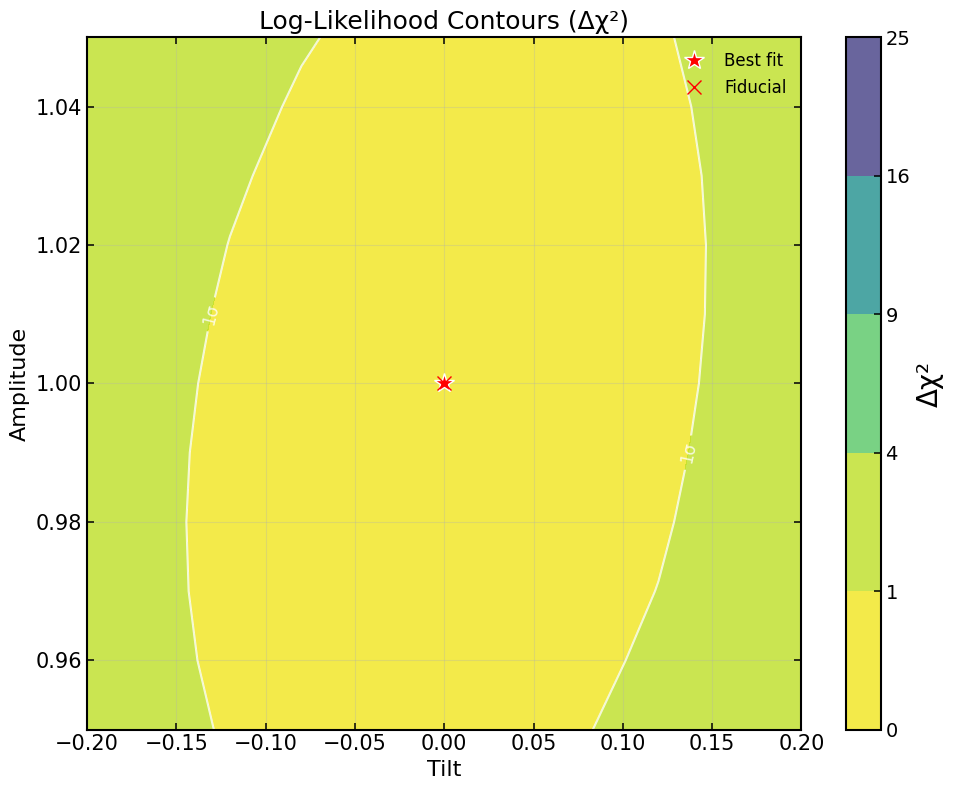

Best-fit parameters: Amplitude = 1.0000, Tilt = 0.0000
Minimum χ² = -773.23
Contour plot with confidence intervals displayed.


In [120]:
# Create contour plot for log-likelihood
fig, ax = plt.subplots(figsize=(10, 8))

# Prepare the data
chi2_mean = chi2_values.mean(axis=-1)
delta_chi2 = chi2_mean - chi2_mean.min()

# Create coordinate grids
tilt_grid, amp_grid = np.meshgrid(
    likelihood.parameter_ranges["tilt"], likelihood.parameter_ranges["amplitude"]
)

# Create filled contour plot
contour_levels = [0, 1, 4, 9, 16, 25]  # Corresponding to 0σ, 1σ, 2σ, 3σ, 4σ, 5σ
contourf = ax.contourf(
    tilt_grid, amp_grid, delta_chi2, levels=contour_levels, cmap="viridis_r", alpha=0.8
)

# Add contour lines
contour_lines = ax.contour(
    tilt_grid,
    amp_grid,
    delta_chi2,
    levels=contour_levels,
    colors="white",
    linewidths=1.5,
    alpha=0.8,
)

# Add contour labels
ax.clabel(contour_lines, inline=True, fontsize=12, fmt="%dσ")

# Find and mark the best-fit point
min_idx = np.unravel_index(np.argmin(chi2_mean), chi2_mean.shape)
best_tilt = likelihood.parameter_ranges["tilt"][min_idx[1]]
best_amp = likelihood.parameter_ranges["amplitude"][min_idx[0]]

ax.plot(
    best_tilt,
    best_amp,
    "r*",
    markersize=15,
    label="Best fit",
    markeredgecolor="white",
    markeredgewidth=1,
)

ax.plot(
    0.0,
    1.0,
    "bx",
    markersize=10,
    label="Fiducial",
    markeredgecolor="red",
    markeredgewidth=1,
)

# Customize the plot
ax.set_xlabel("Tilt", fontsize=16)
ax.set_ylabel("Amplitude", fontsize=16)
ax.set_title("Log-Likelihood Contours (Δχ²)", fontsize=18)

# Add colorbar
cbar = plt.colorbar(contourf, ax=ax, label="Δχ²")
cbar.ax.tick_params(labelsize=14)

# Add legend
ax.legend(fontsize=12)

# Add grid for better readability
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best-fit parameters: Amplitude = {best_amp:.4f}, Tilt = {best_tilt:.4f}")
print(f"Minimum χ² = {chi2_mean.min():.2f}")
print("Contour plot with confidence intervals displayed.")

In [106]:
# Equivalent to running the full likelihood in one step
print("=== Running full likelihood ===")
full_like = PICSLike(param_file)

full_like.run()

=== Running full likelihood ===
2026-02-03 17:08:35 | picslike     | INFO     | PICSLike initialized!
2026-02-03 17:08:35 | picslike     | DEBUG    | Setting up parameter grid...
2026-02-03 17:08:36 | picslike     | DEBUG    | Parameter grid contains 121 points
2026-02-03 17:08:36 | picslike     | INFO     | Starting PICSLike analysis pipeline
2026-02-03 17:08:36 | picslike     | DEBUG    | Reading maps
2026-02-03 17:08:36 | picslike     | VERBOSE  | Signal matrix computed in 0.11 seconds
2026-02-03 17:08:36 | picslike     | VERBOSE  | Signal matrix computed for parameters: (np.float64(0.95), np.float64(-0.2))
2026-02-03 17:08:36 | picslike     | VERBOSE  | Total covariance matrix prepared and inverted
2026-02-03 17:08:37 | picslike     | VERBOSE  | Log-determinant of covariance: 1360.05
2026-02-03 17:08:37 | picslike     | VERBOSE  | Signal matrix computed in 0.14 seconds
2026-02-03 17:08:37 | picslike     | VERBOSE  | Signal matrix computed for parameters: (np.float64(0.95), np.float

In [118]:
full_like.get_chi_squared().shape

(121,)

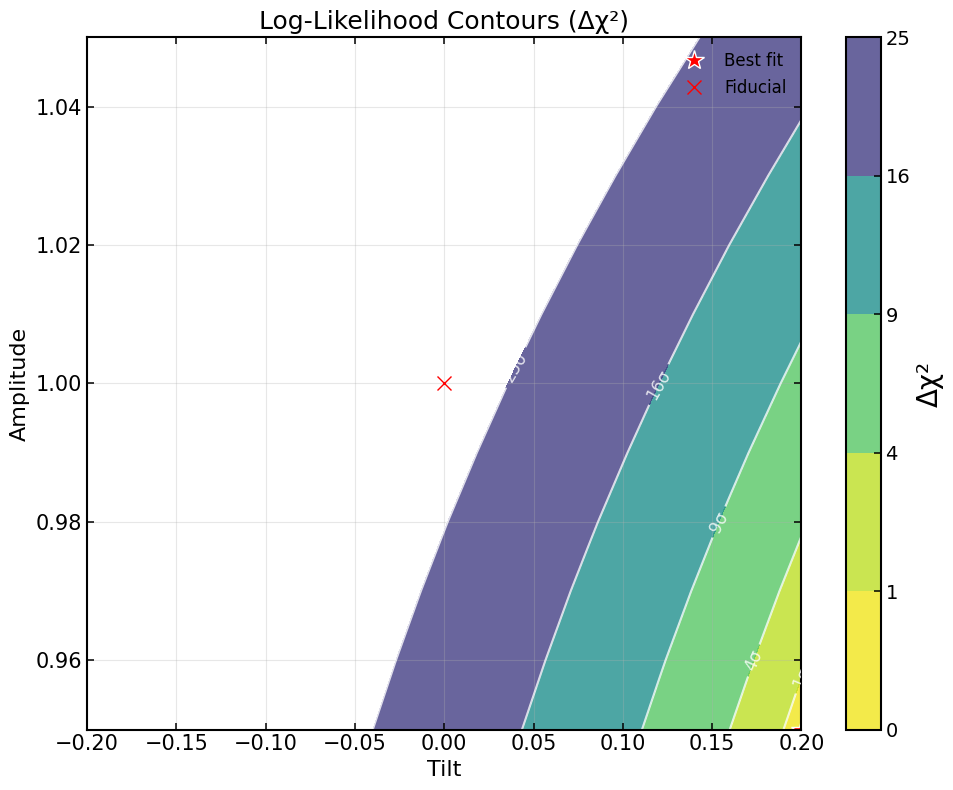

Best-fit parameters: Amplitude = 0.9500, Tilt = 0.2000
Minimum χ² = 545.55
Contour plot with confidence intervals displayed.


In [111]:
# Create contour plot for log-likelihood
fig, ax = plt.subplots(figsize=(10, 8))

# Prepare the data
chi2_mean = full_like.get_chi_squared().reshape(11, -1).T
delta_chi2 = chi2_mean - chi2_mean.min()

# Create coordinate grids
tilt_grid, amp_grid = np.meshgrid(
    full_like.parameter_ranges["tilt"], full_like.parameter_ranges["amplitude"]
)

# Create filled contour plot
contour_levels = [0, 1, 4, 9, 16, 25]  # Corresponding to 0σ, 1σ, 2σ, 3σ, 4σ, 5σ
contourf = ax.contourf(
    tilt_grid, amp_grid, delta_chi2, levels=contour_levels, cmap="viridis_r", alpha=0.8
)

# Add contour lines
contour_lines = ax.contour(
    tilt_grid,
    amp_grid,
    delta_chi2,
    levels=contour_levels,
    colors="white",
    linewidths=1.5,
    alpha=0.8,
)

# Add contour labels
ax.clabel(contour_lines, inline=True, fontsize=12, fmt="%dσ")

# Find and mark the best-fit point
min_idx = np.unravel_index(np.argmin(chi2_mean), chi2_mean.shape)
best_tilt = full_like.parameter_ranges["tilt"][min_idx[1]]
best_amp = full_like.parameter_ranges["amplitude"][min_idx[0]]

ax.plot(
    best_tilt,
    best_amp,
    "r*",
    markersize=15,
    label="Best fit",
    markeredgecolor="white",
    markeredgewidth=1,
)

ax.plot(
    0.0,
    1.0,
    "bx",
    markersize=10,
    label="Fiducial",
    markeredgecolor="red",
    markeredgewidth=1,
)

# Customize the plot
ax.set_xlabel("Tilt", fontsize=16)
ax.set_ylabel("Amplitude", fontsize=16)
ax.set_title("Log-Likelihood Contours (Δχ²)", fontsize=18)

# Add colorbar
cbar = plt.colorbar(contourf, ax=ax, label="Δχ²")
cbar.ax.tick_params(labelsize=14)

# Add legend
ax.legend(fontsize=12)

# Add grid for better readability
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best-fit parameters: Amplitude = {best_amp:.4f}, Tilt = {best_tilt:.4f}")
print(f"Minimum χ² = {chi2_mean.min():.2f}")
print("Contour plot with confidence intervals displayed.")